Setup + load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

dc = pd.read_csv("../data/processed/data_centers_clean.csv")
dc.shape

(74, 16)

Overview

In [2]:
dc.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,74,74,Colossus 2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_h100_equivalents,74.0,NaN,NaN,NaN,163240.6769,201654.163593,0.0,27665.48762,123799.898939,202753.916119,1111672.5619
current_power_mw,74.0,NaN,NaN,NaN,154.483784,186.199831,0.0,29.0,101.5,216.25,946.0
current_total_capital_cost_2025_usd_billions,74.0,NaN,NaN,NaN,5.852155,7.053622,0.0,1.098578,3.845023,8.191982,35.836372
owner,66,17,Google #confident,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
users,53,15,Meta #confident,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
selected_sources,74,74,- [WSJ profile of the Colossus data centers](h...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calculations_sheet,74,74,https://docs.google.com/spreadsheets/d/1_FQATV...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
project,16,7,Stargate #confident,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_chip_types,50,22,B300,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN


First real question — biggest data centers by power

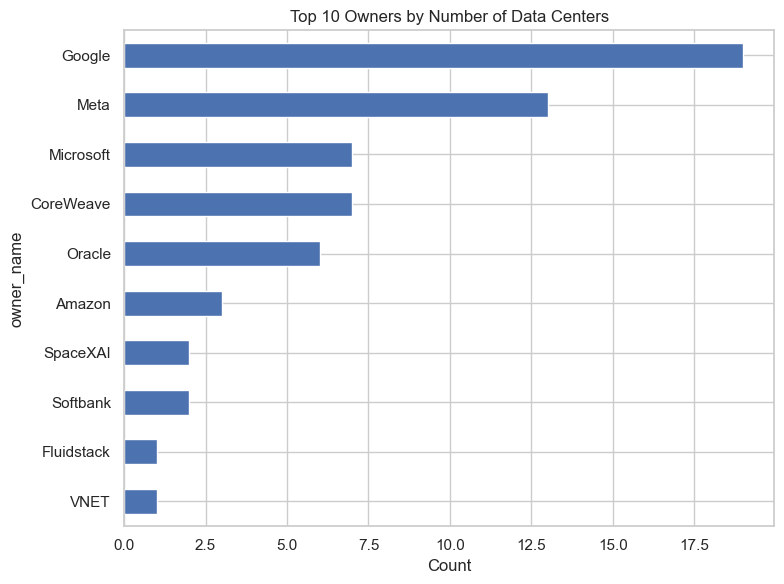

In [5]:
dc = pd.read_csv("../data/processed/data_centers_clean.csv")

plt.figure(figsize=(8, 6))
dc["owner_name"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Owners by Number of Data Centers")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Relationship between power and capital cost — do bigger (more power) data centers cost proportionally more?

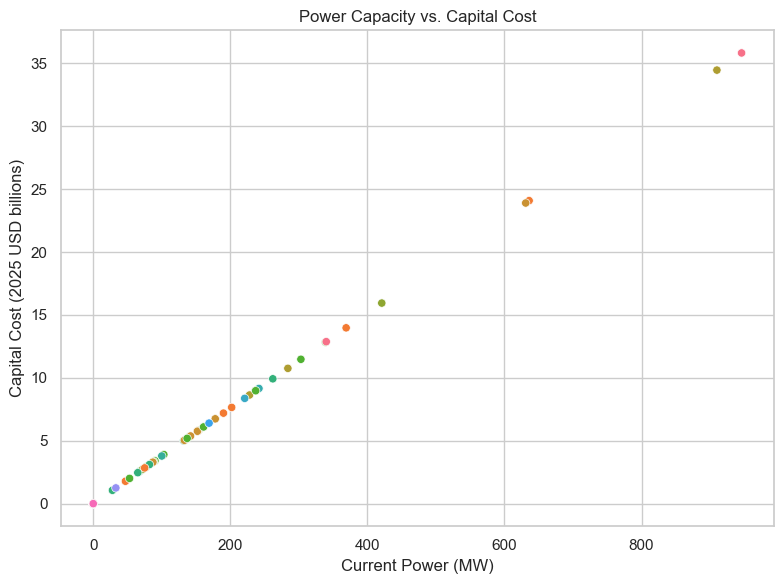

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dc, x="current_power_mw", y="current_total_capital_cost_2025_usd_billions",
                 hue="owner_name", legend=False)
plt.title("Power Capacity vs. Capital Cost")
plt.xlabel("Current Power (MW)")
plt.ylabel("Capital Cost (2025 USD billions)")
plt.tight_layout()
plt.show()

In [7]:
correlation = dc["current_power_mw"].corr(dc["current_total_capital_cost_2025_usd_billions"])
print(f"Correlation: {correlation:.4f}")

Correlation: 1.0000


## Finding: Power and Capital Cost are not independent

Correlation = 1.0000. Capital cost appears to be derived directly from power
capacity (likely `cost = power_mw × constant`), not independently reported.
Treat these as one signal, not two, in any downstream analysis or dashboard —
charting both separately would be redundant.

load and inspect timelines

In [8]:
timelines = pd.read_csv("../data/processed/data_center_timelines_clean.csv", parse_dates=["date"])
timelines["date"].min(), timelines["date"].max()

(Timestamp('2018-12-18 00:00:00'), Timestamp('2030-01-01 00:00:00'))

 power build-out for the top 5 data centers by current power

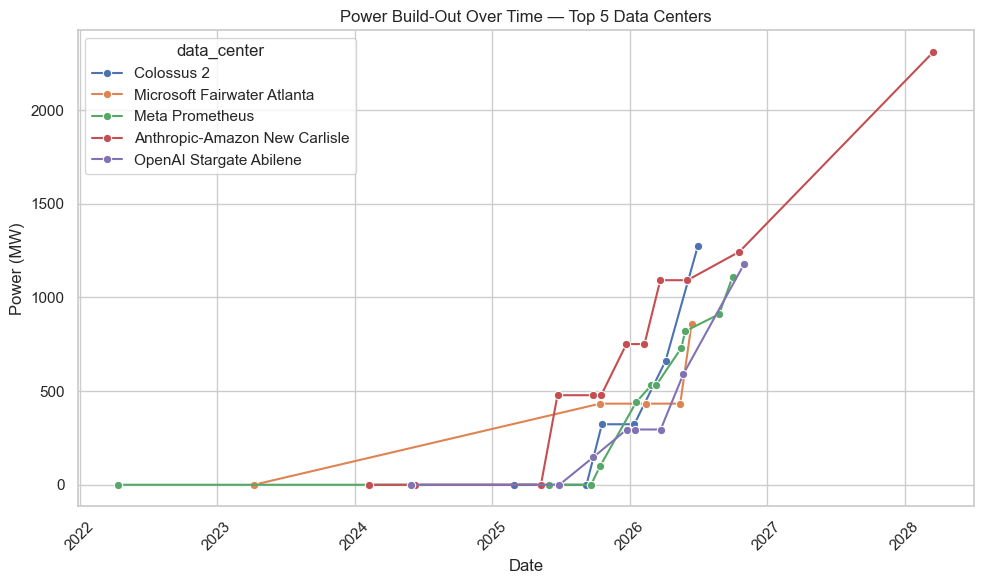

In [9]:
top5_names = dc.sort_values("current_power_mw", ascending=False).head(5)["name"]
top5_timeline = timelines[timelines["data_center"].isin(top5_names)]

plt.figure(figsize=(10, 6))
sns.lineplot(data=top5_timeline, x="date", y="power_mw", hue="data_center", marker="o")
plt.title("Power Build-Out Over Time — Top 5 Data Centers")
plt.xlabel("Date")
plt.ylabel("Power (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()